# Question Answering Chatbot

## Importing the libraries

In [1]:
import re
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Dropout, Activation, Dense,
    Softmax, LSTM, dot, concatenate, TextVectorization
)

## Importing the Dataset


The Dataset used here was taken from the Babi Data Set from Facebook Research.

Full Details: https://www.kaggle.com/datasets/roblexnana/the-babi-tasks-for-nlp-qa-system

- Jason Weston, Antoine Bordes, Sumit Chopra, Tomas Mikolov, Alexander M. Rush,
  "Towards AI-Complete Question Answering: A Set of Prerequisite Toy Tasks",
  http://arxiv.org/abs/1502.05698

## Parsing Stories

In [2]:
def parse_stories(lines):

    data = []
    story = []

    for line in lines:

        line = line.strip()
        line_number, line = line.split(' ', 1)
        line_number = int(line_number)

        if line_number == 1:
            story = []

        if '\t' in line:
            q, a, supporting = line.split('\t')
            q = q.strip().split()
            substory = [x for x in story if x]
            data.append((substory, q, a.strip()))

        else:
            sentence = line.strip().split()
            story.append(sentence)

    return data

## Reading Stories

In [3]:
def read_stories(f):

    with open(f, 'r') as file:
        lines = file.readlines()

    data = parse_stories(lines)
    flattened_data = []

    for story, question, answer in data:
        flattened_story = [word for sentence in story for word in sentence]
        flattened_data.append((flattened_story, question, answer))

    return flattened_data

In [4]:
train_data = read_stories("qa1_train.txt")
test_data = read_stories("qa1_test.txt")

## Exploring the Format of the Data

In [5]:
print(type(train_data))
print(type(test_data))

<class 'list'>
<class 'list'>


In [6]:
print(len(train_data))
print(len(test_data))

10000
1000


In [7]:
print(train_data[0])

(['Mary', 'moved', 'to', 'the', 'bathroom.', 'John', 'went', 'to', 'the', 'hallway.'], ['Where', 'is', 'Mary?'], 'bathroom')


In [8]:
print(' '.join(train_data[0][0]))
print(' '.join(train_data[0][1]))
print(train_data[0][2])

Mary moved to the bathroom. John went to the hallway.
Where is Mary?
bathroom


## Setting up Vocabulary of All Words

In [9]:
vocab = set()

## Extracting Sequences

In [10]:
train_stories = [" ".join(story) for story, _, _ in train_data]
train_questions = [" ".join(question) for _, question, _ in train_data]
train_answers = [answer for _, _, answer in train_data]

In [11]:
test_stories = [" ".join(story) for story, _, _ in test_data]
test_questions = [" ".join(question) for _, question, _ in test_data]
test_answers = [answer for _, _, answer in test_data]

## Finding Max Lengths

In [12]:
all_data = test_data + train_data

In [13]:
max_story_len = max([len(story) for story, _, _ in all_data])
max_question_len = max([len(question) for _, question, _ in all_data])

## Vectorizing the Data

In [14]:
def custom_standardization(input_data):
    lowercase = tf.strings.lower(input_data)
    return tf.strings.regex_replace(lowercase, r"[.!?'\",]", "")

In [15]:
all_texts = (
    train_stories + train_questions + test_stories + test_questions + train_answers + test_answers
)

In [16]:
master_vectorizer = TextVectorization(
    standardize = custom_standardization,
    split = "whitespace",
    output_mode = "int"
)

master_vectorizer.adapt(all_texts)

In [17]:
vocab = master_vectorizer.get_vocabulary()
vocab_size = len(vocab)

In [18]:
print(f"Total clean words : {vocab_size}")
print(f"Top 15 tokens: {vocab[:15]}")

dirty_tokens = [w for w in vocab if '?' in w or '.' in w]
print(f"Dirty tokens remaining : {len(dirty_tokens)}")

Total clean words : 21
Top 15 tokens: ['', '[UNK]', np.str_('to'), np.str_('the'), np.str_('went'), np.str_('sandra'), np.str_('john'), np.str_('daniel'), np.str_('mary'), np.str_('travelled'), np.str_('journeyed'), np.str_('back'), np.str_('bathroom'), np.str_('garden'), np.str_('hallway')]
Dirty tokens remaining : 0


## Creating separate vectorizers

In [20]:
story_vectorizer = TextVectorization(
    standardize = custom_standardization,
    split = "whitespace",
    output_mode = "int",
    output_sequence_length = max_story_len,
    vocabulary = vocab,
)

In [23]:
question_vectorizer = TextVectorization(
    standardize = custom_standardization,
    split = "whitespace",
    output_mode = "int",
    output_sequence_length = max_question_len,
    vocabulary = vocab,
)

## Preparing Vectorized Datasets

In [24]:
inputs_train = story_vectorizer(np.array(train_stories)).numpy()
question_train = question_vectorizer(np.array(train_questions)).numpy()

In [25]:
inputs_test = story_vectorizer(np.array(test_stories)).numpy()
question_test = question_vectorizer(np.array(test_questions)).numpy()

## One-Hot Encoding the Answers

In [43]:
def vectorize_answers(answers, vocab):

    word_to_idx = {word: idx for idx, word in enumerate(vocab)}
    vectorized = np.zeros((len(answers), len(vocab)))

    for idx, answer in enumerate(answers):
        vectorized[idx, word_to_idx[answer.lower()]] = 1.0

    return vectorized

In [44]:
answers_train = vectorize_answers(train_answers, vocab)
answers_test = vectorize_answers(test_answers, vocab)

## Creating the Model (MemN2N)

### Building the Networks

To understand why we chose this setup, make sure to read the paper we are using:

* Sainbayar Sukhbaatar, Arthur Szlam, Jason Weston, Rob Fergus,
  "End-To-End Memory Networks",
  http://arxiv.org/abs/1503.08895

### Placeholders for Inputs

*  We have two inputs, stories and questions. So we need to use placeholders. `Input()` is used to instantiate a Keras tensor.
*  `name` parameter was used to get more readable `model.summary()`

In [45]:
input_sequence = Input((max_story_len,), name = "Story_Input")
question_sequence = Input((max_question_len,), name = "Question_Input")

## Encoders

### Input Encoder m

In [46]:
input_encoded_m = Embedding(input_dim = vocab_size, output_dim = 64)(input_sequence)
input_encoded_m = Dropout(0.3)(input_encoded_m)

### Input Encoder c

In [47]:
input_encoded_c = Embedding(input_dim = vocab_size, output_dim = 64)(input_sequence)
input_encoded_c = Dropout(0.3)(input_encoded_c)

### Question Encoder

In [48]:
question_encoded = Embedding(input_dim = vocab_size, output_dim = 64)(question_sequence)
question_encoded = Dropout(0.3)(question_encoded)

## Computing match matrix (Dot product)

In [49]:
match = dot([input_encoded_m, question_encoded], axes = (2, 2))
match = Softmax(axis = 1)(match)

## Adding match matrix with the second input vector sequence

In [50]:
response = dot([match, input_encoded_c], axes = (1, 1))

## Concatenating response and question vectors

In [51]:
answer = concatenate([response, question_encoded])

## Final Classification Layer

In [52]:
answer = LSTM(64)(answer)
answer = Dropout(0.5)(answer)
answer = Dense(vocab_size)(answer)
answer = Activation('softmax')(answer)

## Compiling the Model

In [53]:
model = Model(
    [input_sequence, question_sequence],
    answer
)

In [54]:
model.compile(
    optimizer = 'rmsprop',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [55]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Story_Input         │ (None, 58)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Question_Input      │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 58, 64)    │      1,344 │ Story_Input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 3, 64)     │      1,344 │ Question_Input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 58, 64)    │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 3, 64)     │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_2 (Dot)         │ (None, 58, 3)     │          0 │ dropout_4[0][0],  │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 58, 64)    │      1,344 │ Story_Input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_1 (Softmax) │ (None, 58, 3)     │          0 │ dot_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 58, 64)    │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_3 (Dot)         │ (None, 3, 64)     │          0 │ softmax_1[0][0],  │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 3, 128)    │          0 │ dot_3[0][0],      │
│ (Concatenate)       │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 21)        │      1,365 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 21)        │          0 │ dense_1[0][0]     │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,805 (214.08 KB)

 Trainable params: 54,805 (214.08 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

In [56]:
history = model.fit(
    [inputs_train, question_train],
    answers_train,
    batch_size = 32,
    epochs = 120,
    validation_data = (
        [inputs_test, question_test],
        answers_test
    )
)

Epoch 1/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.1635 - loss: 1.9546 - val_accuracy: 0.1490 - val_loss: 1.8045
Epoch 2/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1701 - loss: 1.8191 - val_accuracy: 0.1910 - val_loss: 1.7884
Epoch 3/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2461 - loss: 1.7257 - val_accuracy: 0.4050 - val_loss: 1.4354
Epoch 4/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4048 - loss: 1.4047 - val_accuracy: 0.4100 - val_loss: 1.3339
Epoch 5/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4160 - loss: 1.3685 - val_accuracy: 0.4140 - val_loss: 1.3158
Epoch 6/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4067 - loss: 1.3560 - val_accuracy: 0.4310 - val_loss: 1.3040
Epoch 7/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4157 - loss: 1.3458 - val_accuracy: 0.4210 - val_loss: 1.2878
Epoch 8/120
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4125 - loss: 1.3303 - val_a

## Saving the Model

In [57]:
filename = 'Chatbot_120_Epochs.keras'
model.save(filename)

## Evaluating the Model

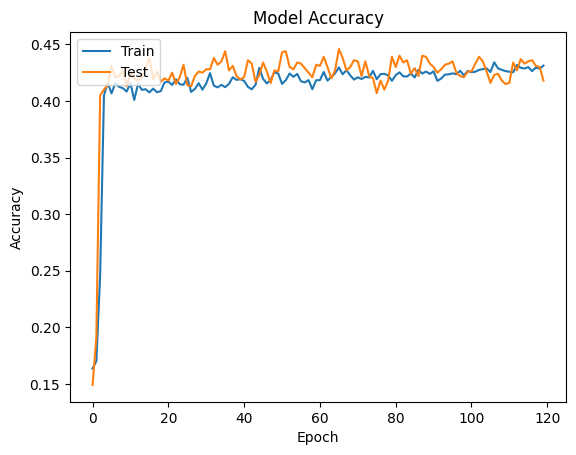

In [58]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

## Evaluating on Given Test Set

In [59]:
pred_results = model.predict([inputs_test, question_test])
val_max = np.argmax(pred_results[0])

print(f"True Test Answer from Data is: {test_answers[0]}")
print(f"Predicted answer is: {vocab[val_max]}")
print(f"Probability of certainty was: {pred_results[0][val_max]:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
True Test Answer from Data is: hallway
Predicted answer is: hallway
Probability of certainty was: 0.5130


## Writing Your Own Stories and Questions

&nbsp; Remember you can only use words from the existing vocabulary

In [60]:
my_story = "Daniel went to the kitchen . Daniel journeyed to the bedroom . Mary moved to the hallway ."
my_question = "Where is Mary ?"

In [61]:
custom_story_vector = story_vectorizer(np.array([my_story])).numpy()
custom_question_vector = question_vectorizer(np.array([my_question])).numpy()

In [62]:
custom_pred = model.predict([custom_story_vector, custom_question_vector])
custom_val_max = np.argmax(custom_pred[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [63]:
print(f"Custom Story: {my_story}")
print(f"Custom Question: {my_question}")
print(f"Predicted answer: {vocab[custom_val_max]}")
print(f"Probability of certainty: {custom_pred[0][custom_val_max]:.4f}")

Custom Story: Daniel went to the kitchen . Daniel journeyed to the bedroom . Mary moved to the hallway .
Custom Question: Where is Mary ?
Predicted answer: hallway
Probability of certainty: 0.3613


## Extracting all vocabulary probabilities

In [64]:
prediction_distribution = custom_pred[0]
vocab_probabilities = list(zip(vocab, prediction_distribution))
sorted_probabilities = sorted(vocab_probabilities, key = lambda x: x[1], reverse = True)

In [65]:
print("\n--- Model's Top 10 Probabilities ---")

for word, probability in sorted_probabilities[:10]:
    percentage = probability * 100
    print(f"'{word:<8}' -> {percentage:.4f}%")


--- Model's Top 10 Probabilities ---
'hallway ' -> 36.1326%
'bedroom ' -> 33.6985%
'kitchen ' -> 30.1647%
'bathroom' -> 0.0016%
'garden  ' -> 0.0014%
'office  ' -> 0.0010%
'mary    ' -> 0.0000%
'went    ' -> 0.0000%
'john    ' -> 0.0000%
'sandra  ' -> 0.0000%
